In [ ]:
from google.colab import files
upload =files.upload()

Saving uber_sampled_data.csv to uber_sampled_data.csv


<img src="https://img.pikbest.com/photo/20240828/futuristic-gps-navigation-map-with-glowing-location-pins-4k-photo-background_10767034.jpg!bw700">

# **Project Description**
The project focuses on analyzing Uber pickup data to understand ride demand patterns across location and time. Since the dataset does not contain predefined labels, it initially relies on unsupervised learning to discover hidden patterns.

First, a spatial analysis is performed using only geographic features (latitude & longitude) to identify high-demand areas (hotspots) and understand how pickups are distributed across the map.

Then, the analysis is extended to spatial + temporal analysis by incorporating time-related features (such as hour), allowing deeper insights into how demand changes in the same locations over different time periods.

Clustering algorithms like K-Means and DBSCAN are applied to detect natural groupings and hotspots.

Finally, the project is transformed into a supervised learning problem by using the generated cluster labels as targets. A model such as KNN is trained to predict the cluster of new data points, making the solution practical and ready for real-world deployment.

---

#**Data Description**
The Uber Pickups dataset contains detailed records of Uber rides in New York City, where each row represents a pickup request recorded at a specific time and location. The data includes the full timestamp of the ride (Date/Time) along with geographic coordinates (Latitude and Longitude) that precisely identify the pickup location on the map. It also includes a (Base) column, which represents the code of the operating company or dispatch center responsible for the ride. This dataset enables the analysis of both temporal and spatial demand patterns, such as peak hours and high-demand areas.

---

# **Column-by-column description**
1. **Date/Time**
* Represents the date and time when the pickup request was made, and is used to analyze temporal patterns such as peak hours and busy days.
2. **Lat (Latitude)**
* Indicates the geographic latitude of the pickup location, defining the north-south position on the map.
3. **Lon (Longitude)**
* Represents the geographic longitude, defining the east-west position and completing the exact location with latitude.
4. **Base**
* Refers to the code of the operating company or dispatch center responsible for the ride, and can be used for additional analysis but is not essential for clustering.

---

# **The Goal**
* Start with spatial analysis, then enhance it with temporal features
* Discover hidden demand patterns
* Convert insights into a predictive, deployable system

# **The Code**

In [ ]:
# import
import pandas as pd
# Load data
orignal_data = pd.read_csv("uber_sampled_data.csv")
# check
orignal_data.head()

,Date/Time,Lat,Lon,Base
0,4/9/2014 10:21:00,40.8021,-73.9654,B02598
1,4/14/2014 4:55:00,40.6462,-73.7769,B02764
2,4/23/2014 9:52:00,40.7747,-73.9603,B02598
3,4/4/2014 23:32:00,40.7150,-74.0157,B02682
4,4/5/2014 19:57:00,40.7335,-74.0080,B02598


In [ ]:
# copy dataframe
df = orignal_data.copy()

In [ ]:
# Library use

import numpy as np
# Importing NumPy for numerical operations (arrays, math functions, etc.)
import pandas as pd
# Importing Pandas for data manipulation and analysis (DataFrames, CSV files, etc.)
import matplotlib.pyplot as plt
# Importing Matplotlib's Pyplot for basic plotting and data visualization
import seaborn as sns
import plotly.express as px
# Importing Seaborn,plotly for advanced statistical data visualization (built on top of Matplotlib)

from sklearn.impute import SimpleImputer, KNNImputer
# SimpleImputer => Fills missing values using simple strategies like mean, median, or most frequent.
# KNNImputer => Fills missing values using K-Nearest Neighbors based on similarities between rows.

from sklearn.preprocessing import StandardScaler
# use to scale the data

# Import Models
from sklearn.cluster import KMeans , DBSCAN
from sklearn.metrics import silhouette_score


# **Exploratory Data Analysis (EDA)**


In [ ]:
# Display Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Date/Time  180000 non-null  object 
 1   Lat        180000 non-null  float64
 2   Lon        180000 non-null  float64
 3   Base       180000 non-null  object 
dtypes: float64(2), object(2)
memory usage: 5.5+ MB


In [ ]:
# display num of colums and rows
df.shape

(180000, 4)

In [ ]:
# generate quick statistical summaries for the numeric columns
df.describe()

,Lat,Lon
count,180000.000000,180000.000000
mean,40.739419,-73.973362
std,0.039731,0.056648
min,39.978200,-74.667400
25%,40.721200,-73.996600
50%,40.742500,-73.983400
75%,40.761100,-73.965900
max,41.233900,-72.696600


In [ ]:
# generates statistical summaries for object (categorical/text) columns
df.describe(include="object")

,Date/Time,Base
count,180000,180000
unique,119218,5
top,6/13/2014 18:52:00,B02598
freq,10,56878


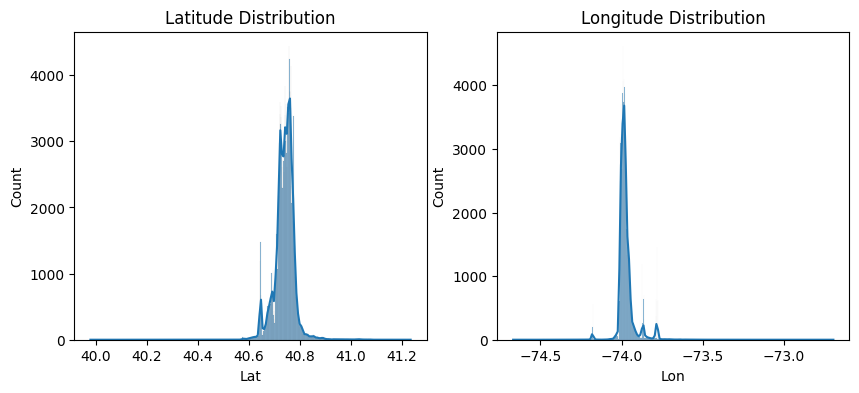

In [ ]:
# Draw histogram for columns (Lat & Lon)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df["Lat"], kde=True)
plt.title("Latitude Distribution")

plt.subplot(1,2,2)
sns.histplot(df["Lon"], kde=True)
plt.title("Longitude Distribution")

plt.show()

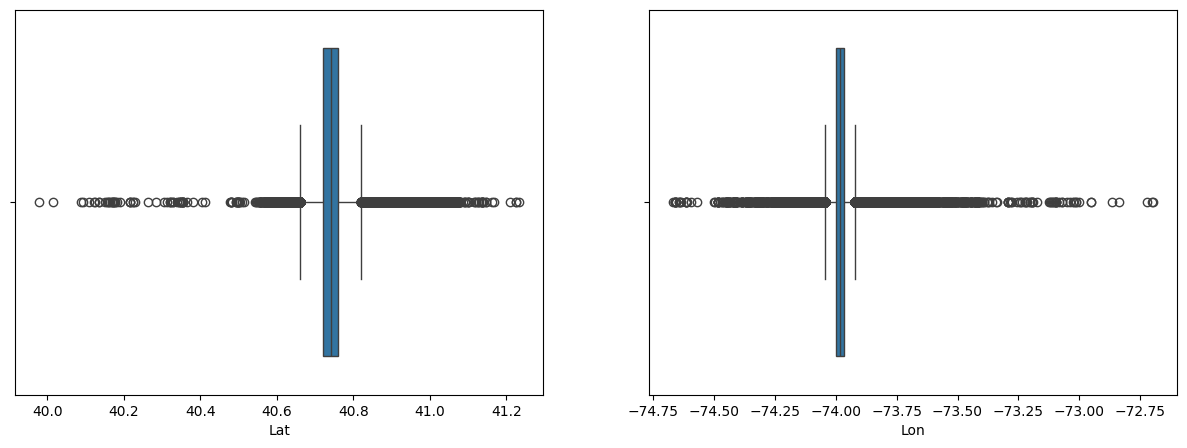

In [ ]:

# Draw Boxblot for columns (Lat & Lon)
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(x=df["Lat"])

plt.subplot(1,2,2)
sns.boxplot(x=df["Lon"])

plt.show()

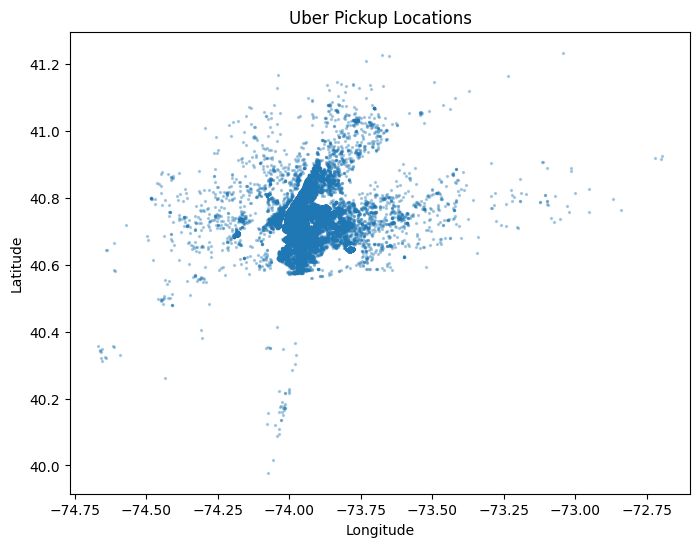

In [ ]:
# Draw Scatter to show the locations of the overcrowding
plt.figure(figsize=(8,6))
plt.scatter(df["Lon"], df["Lat"], s=2 , alpha=0.3)
plt.title("Uber Pickup Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

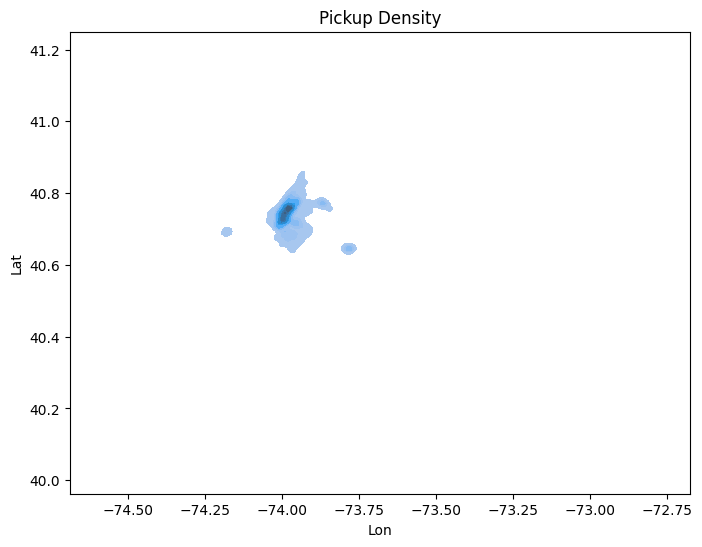

In [ ]:
# Draw kdeplot to encure the locations of the overcrowding
plt.figure(figsize=(8,6))
sns.kdeplot(
    x=df["Lon"],
    y=df["Lat"],
    fill=True
)
plt.title("Pickup Density")
plt.show()

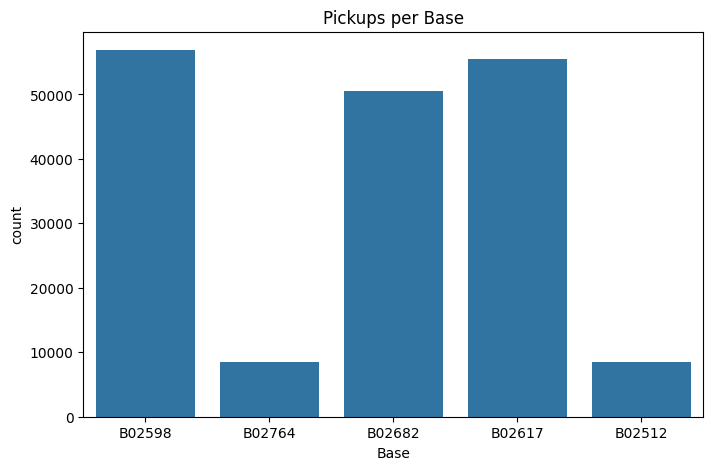

In [ ]:
# Draw histogram to show Pickups per Base
plt.figure(figsize=(8,5))
sns.countplot(x= df["Base"])
plt.title("Pickups per Base")
plt.show()

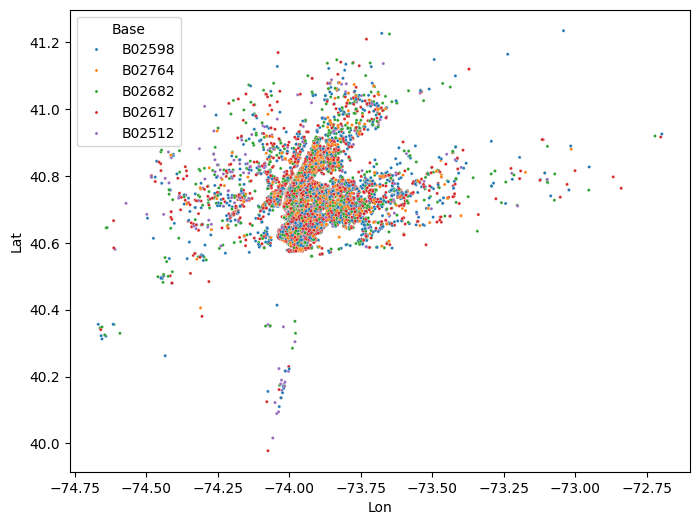

In [ ]:
# Show the locations of the overcrowding for each base
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="Lon",
    y="Lat",
    hue="Base",
    data=df,
    s=5
)
plt.show()

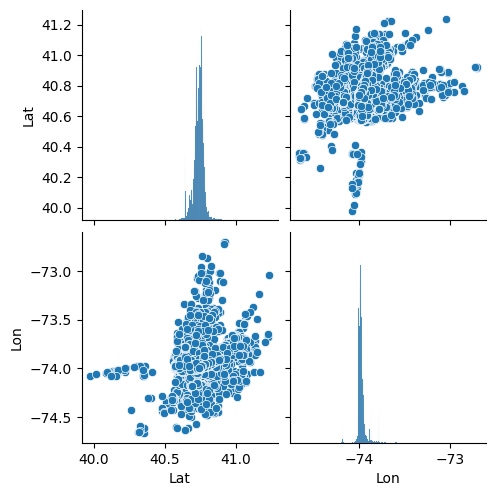

In [ ]:
sns.pairplot(df[["Lat", "Lon"]])

**EDA Notes**

* Data does not contain any missing values.
* Pickup locations are highly concentrated within a narrow geographic range, indicating dense urban activity.
* The data contains several outliers, representing pickups in less frequent or distant locations.
* The spatial distribution shows clear clustering patterns, with a dense central region and scattered outer points.
* A strong hotspot is observed, indicating a high concentration of pickups in central urban areas.
* Pickup distribution across bases is imbalanced, with certain bases handling significantly more requests.
* All bases operate across similar geographic regions, suggesting no strong spatial separation between them.
* The pairplot confirms a structured spatial relationship, supporting the presence of clustering patterns.

# **Data Proccessing Pipline**


1. Genralization
2. Feature Engineering
3. Handling Outliers
4. Visualization
5. Feature Selection
6. Scalling

**1- Genralization**

In [ ]:
# Check
df.head()

,Date/Time,Lat,Lon,Base
0,4/9/2014 10:21:00,40.8021,-73.9654,B02598
1,4/14/2014 4:55:00,40.6462,-73.7769,B02764
2,4/23/2014 9:52:00,40.7747,-73.9603,B02598
3,4/4/2014 23:32:00,40.7150,-74.0157,B02682
4,4/5/2014 19:57:00,40.7335,-74.0080,B02598


In [ ]:
# show types of columns
df.dtypes

,0
Date/Time,object
Lat,float64
Lon,float64
Base,object


In [ ]:
# Code to seperate the numerical columns and categorical columns
cat_cols = [col for col in df.columns if df[col].dtypes == "object"]
num_cols = [col for col in df.columns if df[col].dtypes != "object"]
# Print
print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['Date/Time', 'Base']
Numerical columns: ['Lat', 'Lon']


In [ ]:
# code for remove right and lift spaces
for col in cat_cols:
  df[col] = df[col].str.strip()

In [ ]:
# Check
df.nunique()

,0
Date/Time,119218
Lat,3627
Lon,4249
Base,5


**2- Feature Engineering**

In [ ]:
# Check
df.head()

,Date/Time,Lat,Lon,Base
0,4/9/2014 10:21:00,40.8021,-73.9654,B02598
1,4/14/2014 4:55:00,40.6462,-73.7769,B02764
2,4/23/2014 9:52:00,40.7747,-73.9603,B02598
3,4/4/2014 23:32:00,40.7150,-74.0157,B02682
4,4/5/2014 19:57:00,40.7335,-74.0080,B02598


In [ ]:
# convert data to datatime
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

In [ ]:
# create column "hour" from Date/Time
df["hour"] = df["Date/Time"].dt.hour

In [ ]:
# Create column day_of_week from Date/Time
df["day_of_week"] = df["Date/Time"].dt.weekday

In [ ]:
# Create column is_wekend from column day_of_week
# Note => The days of the week start from Monday to Sunday (0 to 6)
df["is_wekend"] = df["day_of_week"].apply(lambda x: 1 if x >= 5 else 0 )

In [ ]:
# Create column month from Date/Time
df["month"] = df["Date/Time"].dt.month

In [ ]:
df.head()

,Date/Time,Lat,Lon,Base,hour,day_of_week,is_wekend,month
0,2014-04-09 10:21:00,40.8021,-73.9654,B02598,10,2,0,4
1,2014-04-14 04:55:00,40.6462,-73.7769,B02764,4,0,0,4
2,2014-04-23 09:52:00,40.7747,-73.9603,B02598,9,2,0,4
3,2014-04-04 23:32:00,40.7150,-74.0157,B02682,23,4,0,4
4,2014-04-05 19:57:00,40.7335,-74.0080,B02598,19,5,1,4


**3- Handling Outliers**

In [ ]:
# show description
df.describe()

,Date/Time,Lat,Lon,hour,day_of_week,is_wekend,month
count,180000,180000.000000,180000.000000,180000.000000,180000.000000,180000.000000,180000.00000
mean,2014-07-01 18:04:31.075666944,40.739419,-73.973362,14.246322,2.962789,0.247667,6.50000
min,2014-04-01 00:11:00,39.978200,-74.667400,0.000000,0.000000,0.000000,4.00000
25%,2014-05-16 13:23:45,40.721200,-73.996600,10.000000,1.000000,0.000000,5.00000
50%,2014-07-01 00:00:30,40.742500,-73.983400,15.000000,3.000000,0.000000,6.50000
75%,2014-08-15 22:47:00,40.761100,-73.965900,19.000000,4.000000,0.000000,8.00000
max,2014-09-30 22:59:00,41.233900,-72.696600,23.000000,6.000000,1.000000,9.00000
std,NaN,0.039731,0.056648,5.947273,1.869436,0.431658,1.70783


**Insights**
* Pickup locations are concentrated within a defined geographic range, with some distant points indicating potential outliers.
* The geographic data is tightly clustered around central values, indicating dense urban pickup regions.
* Pickup activity spans the full day, with a slight concentration around afternoon hours.
* Pickup requests are relatively evenly distributed across weekdays.
* Most pickups occur during weekdays, with a smaller portion during weekends.
* The dataset spans multiple months, allowing for seasonal variation analysis.


In [ ]:
# containous_cols = ["Lon", "Lat"]

In [ ]:
# # This function removes outliers from the specified column (col) in df using the IQR method
# # keeping only the rows with values inside the normal range (between the upper and lower fences).
# # Returns a cleaned DataFrame without outlier rows.

# def outliers_delet(col):
#   Q1=df[col].quantile(.25)
#   Q3=df[col].quantile(.75)
#   IQR=Q3-Q1
#   upper_fence=Q3+1.5*IQR
#   lower_fence=Q1-1.5*IQR

#   df_no_outliers = df[(df[col] >= lower_fence) & (df[col] <= upper_fence)]
#   return df_no_outliers

In [ ]:
# # The code loops through each numerical column in the num_cols list and applies the outliers_delet() function to each one.
# # Remove the outliers from every numerical column
# for col in containous_cols:
#     df = outliers_delet(col)

In [ ]:
# # Code to draw the Boxplot and histogram for each column after deleting outliers
# for col in containous_cols:
#   fig ,ax =plt.subplots(1,2,figsize=(15,5))

#   # Histogram
#   sns.histplot(df[col], kde=True , ax=ax[0])
#   ax[0].set_title(f"Histogram of {col}")

#   # Boxplot
#   sns.boxplot(x=df[col], ax=ax[1])
#   ax[1].set_title(f"Boxplot of {col}")

**Insight(Delete Outliers)**

Outlier removal was evaluated; however, it was found to negatively impact model performance. The extreme values in the dataset represent valid geographic locations (e.g., less frequent or peripheral pickup areas) rather than data errors. Removing these points led to a loss of important spatial information and reduced the clustering quality, as reflected in lower silhouette scores. Therefore, retaining outliers provided a more accurate representation of real-world demand patterns and improved model effectiveness.

**4- Visualization**

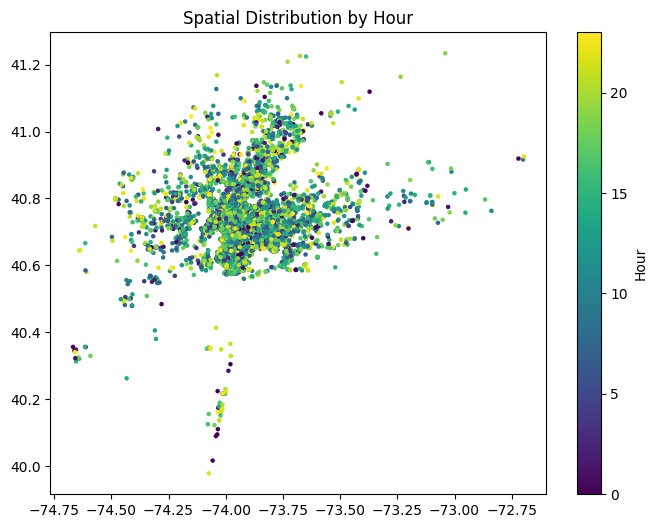

In [ ]:
# This plot shows the distribution of trips across different hours of the day
plt.figure(figsize=(8,6))
plt.scatter(df["Lon"], df["Lat"], c=df["hour"], cmap="viridis", s=5)
plt.colorbar(label="Hour")
plt.title("Spatial Distribution by Hour")
plt.show()

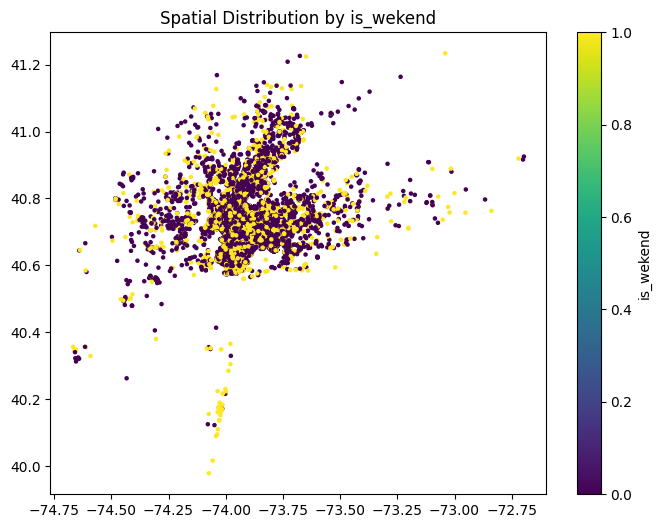

In [ ]:
# This visualization compares trip locations between weekdays and weekends
plt.figure(figsize=(8,6))
plt.scatter(df["Lon"], df["Lat"], c=df["is_wekend"], cmap="viridis", s=5)
plt.colorbar(label="is_wekend")
plt.title("Spatial Distribution by is_wekend")
plt.show()

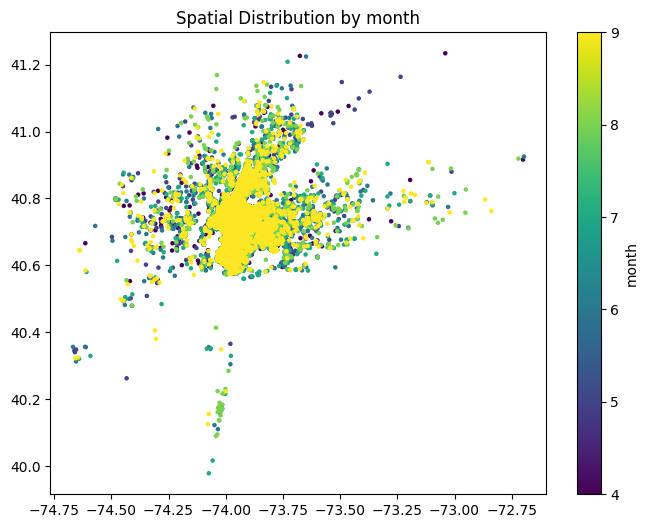

In [ ]:
# This visualization compares trip locations between weekdays and weekends
plt.figure(figsize=(8,6))
plt.scatter(df["Lon"], df["Lat"], c=df["month"], cmap="viridis", s=5)
plt.colorbar(label="month")
plt.title("Spatial Distribution by month")
plt.show()

**Insight**

The spatial distribution of trips remains consistent across different hours, weekends, and months, indicating that demand locations are stable over time. However, temporal features such as hour may still influence demand intensity rather than location.

5- Feature Selection

In [ ]:
# Selected feature which has good affect on the target and remove others.
selected_features = [
  "Lat",
  "Lon",
  "hour",
  "is_wekend",
]


# Drop unimportant features
df = df.drop(columns=[
  "Date/Time",
  "day_of_week",
  "Base",
  "month"
])

In [ ]:
# Check
df.head()

,Lat,Lon,hour,is_wekend
0,40.8021,-73.9654,10,0
1,40.6462,-73.7769,4,0
2,40.7747,-73.9603,9,0
3,40.7150,-74.0157,23,0
4,40.7335,-74.0080,19,1


**6- Scalling**

In [ ]:
# First expermint start with 2 features
# Note => I started with spatial clustering using only latitude and longitude
# to capture geographic patterns before adding temporal features.
x = df[["Lat", "Lon"]]

In [ ]:
# Second experiment using 3 features
# Note => This step extends the previous spatial clustering by including the "hour" feature
# to capture both geographic and temporal patterns (spatio-temporal clustering).
y = df[["Lat", "Lon", "hour"]]

In [ ]:
# Object
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_scaled = scaler_x.fit_transform(x)
y_scaled = scaler_y.fit_transform(y)
# To reduse the use of memory
x_scaled = x_scaled.astype("float32")
y_scaled = y_scaled.astype("float32")

In [ ]:
# Check
x_scaled[:5]

array([[ 1.5776265 ,  0.14055543],
       [-2.34625   ,  3.4681306 ],
       [ 0.8879907 ,  0.23058532],
       [-0.61460984, -0.7473864 ],
       [-0.14897983, -0.6114589 ]], dtype=float32)

In [ ]:
# check
y_scaled[:5]

array([[ 1.5776265 ,  0.14055543, -0.7139968 ],
       [-2.34625   ,  3.4681306 , -1.7228653 ],
       [ 0.8879907 ,  0.23058532, -0.8821416 ],
       [-0.61460984, -0.7473864 ,  1.4718851 ],
       [-0.14897983, -0.6114589 ,  0.79930604]], dtype=float32)

#**Modelling Step**


1. Baseline Models
2. Elbow Method
3. Hyperparameter Tuning
4. Add Clusters
5. Visualization
6. Evaluation
7. Interpretation (Insights)


# First Expermient
using >> x = df[["Lat", "Lon"]]

**1- Baseline Models**

In [ ]:
# First model (KMeans)
# Object
kmeans = KMeans(n_clusters=5, n_init=3 ,max_iter=100)
# fit
kmeans.fit(x_scaled)


KMeans(max_iter=100, n_clusters=5, n_init=3)

In [ ]:
# calculate inertia
inertia = kmeans.inertia_
print("Inertia:", inertia)

Inertia: 122771.75


In [ ]:
# Take Simple Random data from x_scaled to applied on DBSCAN
# Note => DBSCAN was applied on a sampled dataset due to its computational complexity.
df_sample = df.sample(30000, random_state=42)
x_sample = df_sample[["Lat", "Lon"]]
# scaled using scaller
x_sample_scaled = scaler_x.transform(x_sample)

In [ ]:
# Second model (DBSCAN)
# object
dbscan = DBSCAN(eps=0.5, min_samples=5)
# fit
dbscan.fit(x_sample_scaled)

DBSCAN()

**2- Elbow Method**

In [ ]:
# Elpow method
sse = []
for k in range(1,16):
  kmeans = KMeans(n_clusters=k, n_init=3 ,max_iter=100)
  kmeans.fit(x_scaled)
  sse.append(kmeans.inertia_)

print(sse)

[360004.03125, 256249.515625, 177878.890625, 145768.234375, 122769.25, 105180.875, 83629.09375, 73268.265625, 65694.9765625, 57095.234375, 51040.42578125, 44751.25, 41817.3125, 37815.62109375, 35760.62109375]


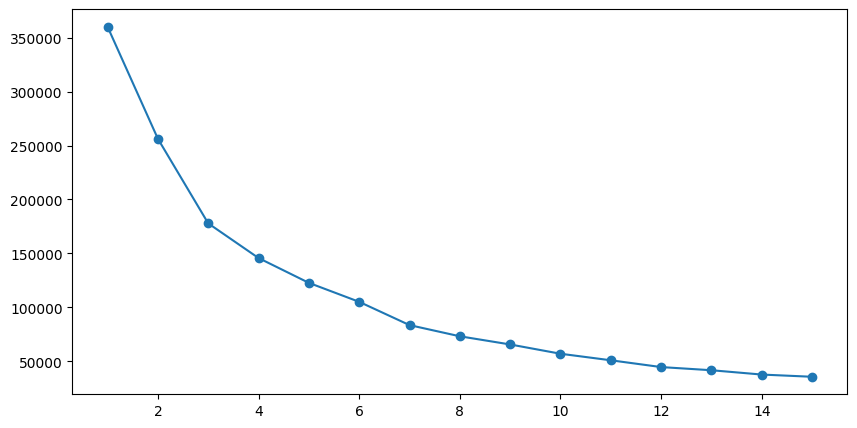

In [ ]:
# show the result in digram
plt.figure(figsize=(10,5))
plt.plot(range(1,16), sse, marker="o")

**Insight** => The Elbow Method indicates that the optimal number of clusters is around (4,5,6) , where the rate of decrease in inertia starts to slow down significantly, suggesting diminishing returns for higher values of k.

**3- Hyperparameter Tuning**

1- First Kmeans

In [ ]:

# Train model when n=4
kmeans_4 = KMeans(n_clusters=4, random_state=42 ,n_init= 3 , max_iter= 100)
labels_4 = kmeans_4.fit_predict(x_scaled)
# calc score of the model
score_4 = silhouette_score(x_scaled, labels_4)
print(score_4)

0.42789015


In [ ]:
# Train model when n=5
kmeans_5 = KMeans(n_clusters=5, random_state=42 ,n_init= 3 , max_iter= 100)
labels_5 = kmeans_5.fit_predict(x_scaled)
# calc score of the model
score_5 = silhouette_score(x_scaled, labels_5)
print(score_5)

0.4438565


In [ ]:
# Train model when n=6
kmeans_6 = KMeans(n_clusters=6, random_state=42 ,n_init=  10, max_iter= 200)
labels_6 = kmeans_6.fit_predict(x_scaled)
# calc score of the model
score_6 = silhouette_score(x_scaled, labels_6)
print(score_6)

0.45503962


In [ ]:
# Final Kmeans Model
final_kmeans = KMeans(n_clusters=6, random_state=42 ,n_init=  10, max_iter= 200)
final_kmeans_labels = final_kmeans.fit_predict(x_scaled)

**Insight** => The optimal number of clusters was found to be k = 6 based on the highest Silhouette Score, indicating better cluster separation and cohesion.

Note => Although higher values of k may slightly improve the score, k = 6 was chosen to maintain a balance between performance and interpretability.

2- Second DBSCAN

In [ ]:
# First we change the value of ebs
ebs_values = [.1 ,.3 ,.5 ,.7 ,.9]

for n_ebs in ebs_values:
  dbscan = DBSCAN(eps=n_ebs , min_samples=5)
  labels = dbscan.fit_predict(x_sample_scaled)

  # Detrmine number of cluster
  n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

  # Detrmine noise ratio
  noise_ratio = np.sum(labels == -1) / len(labels)

  # show the result
  print(f"eps={n_ebs}")
  print("Number of clusters:", n_clusters)
  print("Noise ratio:", noise_ratio)
  print("*"*50)

eps=0.1
Number of clusters: 43
Noise ratio: 0.02666666666666667
**************************************************
eps=0.3
Number of clusters: 13
Noise ratio: 0.008866666666666667
**************************************************
eps=0.5
Number of clusters: 10
Noise ratio: 0.005733333333333333
**************************************************
eps=0.7
Number of clusters: 8
Noise ratio: 0.003966666666666667
**************************************************
eps=0.9
Number of clusters: 2
Noise ratio: 0.002533333333333333
**************************************************


In [ ]:
# Second change the value of min_samples
min_samples_values = [3 ,5 ,8 ,10]
for n_min_samples in min_samples_values:
  dbscan = DBSCAN(eps=.5 , min_samples=n_min_samples)
  labels = dbscan.fit_predict(x_sample_scaled)

  # Detrmine number of cluster
  n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

  # Detrmine noise ratio
  noise_ratio = np.sum(labels == -1) / len(labels)

  # Show the result
  print(f"min_samples={n_min_samples}")
  print("Number of clusters:", n_clusters)
  print("Noise ratio:", noise_ratio)
  print("*"*50)



min_samples=3
Number of clusters: 24
Noise ratio: 0.0037
**************************************************
min_samples=5
Number of clusters: 10
Noise ratio: 0.005733333333333333
**************************************************
min_samples=8
Number of clusters: 4
Noise ratio: 0.008033333333333333
**************************************************
min_samples=10
Number of clusters: 2
Noise ratio: 0.009166666666666667
**************************************************


In [ ]:
# final DBSCAN Model
final_dbscan = DBSCAN(eps=.5 , min_samples=5)
final_dbscan_labels = final_dbscan.fit_predict(x_sample_scaled)


**Insight**
* The optimal eps value was found to be 0.5 as it provides a balanced number of clusters with minimal noise, avoiding both over-segmentation and under-clustering.
* The optimal min_samples value was found to be 5, as it provides a balanced number of clusters while avoiding both excessive fragmentation and over-merging.

**4- Add Cluster**

In [ ]:
# Add Kmean cluster
df["kmeans_cluster"] = final_kmeans_labels

In [ ]:
# Add DBSCAN Cluster
df_sample["dbscan_cluster"] = final_dbscan_labels

In [ ]:
# Check
df.head()

,Lat,Lon,hour,is_wekend,kmeans_cluster
0,40.8021,-73.9654,10,0,1
1,40.6462,-73.7769,4,0,4
2,40.7747,-73.9603,9,0,1
3,40.7150,-74.0157,23,0,3
4,40.7335,-74.0080,19,1,3


In [ ]:
# Check
df_sample.head()

,Lat,Lon,hour,is_wekend,dbscan_cluster
123137,40.7044,-73.9866,2,0,0
130504,40.7573,-73.9896,6,0,0
31166,40.6904,-74.1784,13,1,1
26262,40.7325,-73.9853,23,1,0
64868,40.7588,-73.9939,15,1,0


**Insight** => Cluster labels were added to the dataset to enable further analysis and visualization.

**5- Visualization**

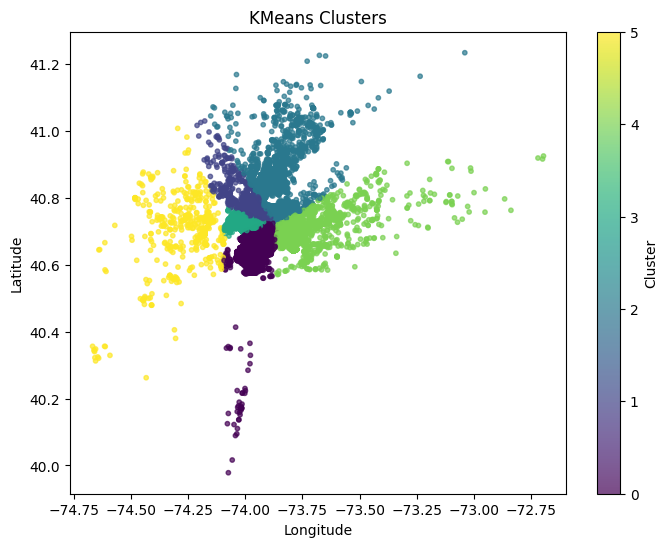

In [ ]:
# Display Kmeans cluster in Scatter
plt.figure(figsize=(8,6))
plt.scatter(df["Lon"], df["Lat"], c=df["kmeans_cluster"], cmap="viridis", s=10, alpha=0.7)
plt.colorbar(label="Cluster")
plt.title("KMeans Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

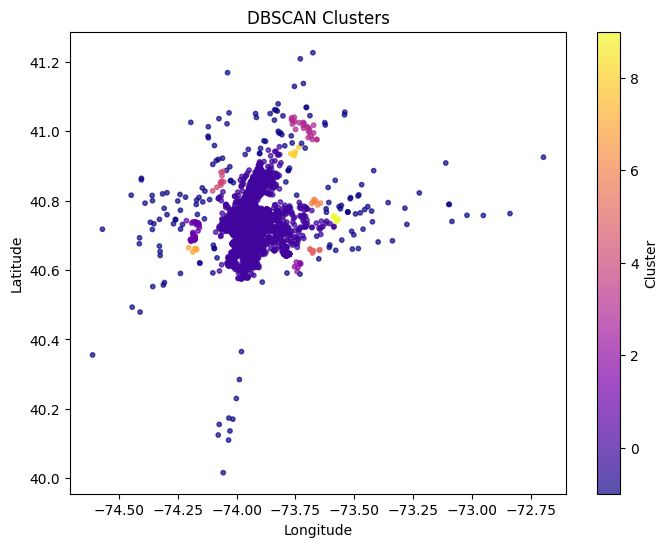

In [ ]:
# Display DBSCAN cluster in Scatter
plt.figure(figsize=(8,6))
plt.scatter(df_sample["Lon"], df_sample["Lat"], c=df_sample["dbscan_cluster"], cmap="plasma", s=10, alpha=0.7)
plt.colorbar(label="Cluster")
plt.title("DBSCAN Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**Insight** => KMeans was used for spatial segmentation, while DBSCAN was used to detect high-density pickup hotspots and outliers. Both models complement each other to provide a comprehensive understanding of the data.

**6- Final Evalution**

In [ ]:
# Evalution Kmeans

kmeans_score = silhouette_score(x_scaled, df["kmeans_cluster"])
print("KMeans Silhouette:", kmeans_score)

KMeans Silhouette: 0.45503962


In [ ]:
# Evalution DBSCAN

# Filter noise
mask = final_dbscan_labels != -1

dbscan_score = silhouette_score(x_sample_scaled[mask], labels[mask])
print("DBSCAN Silhouette:", dbscan_score)

DBSCAN Silhouette: 0.6699886132927269


# Second Expermient
using >> y = df[["Lat", "Lon", "hour"]]

**1- Baseline Models**

In [ ]:
# First model (KMeans)
# Object
kmeans_2 = KMeans(n_clusters=5, n_init=3 ,max_iter=100)
# fit
kmeans_2.fit(y_scaled)

KMeans(max_iter=100, n_clusters=5, n_init=3)

In [ ]:
# Take Simple Random data from x_scaled to applied on DBSCAN
# Note => DBSCAN was applied on a sampled dataset due to its computational complexity.
y_sample = df_sample[["Lat", "Lon" ,"hour"]]
# scaled using scaller
y_sample_scaled = scaler_y.transform(y_sample)

In [ ]:
# Second model (DBSCAN)
# object
dbscan_2 = DBSCAN(eps=0.5, min_samples=5)
# fit
dbscan_2.fit(y_sample_scaled)


DBSCAN()

**2- Elbow Method**

In [ ]:
# Elpow method
sse_2 = []
for k in range(1,16):
  kmeans_2 = KMeans(n_clusters=k, n_init=3 ,max_iter=100)
  kmeans_2.fit(y_scaled)
  sse_2.append(kmeans_2.inertia_)

print(sse_2)

[540002.4375, 409339.71875, 310486.34375, 256462.03125, 225673.203125, 202277.046875, 188194.71875, 164344.859375, 149191.21875, 135676.734375, 123990.859375, 116386.90625, 109641.0625, 104359.375, 96709.78125]


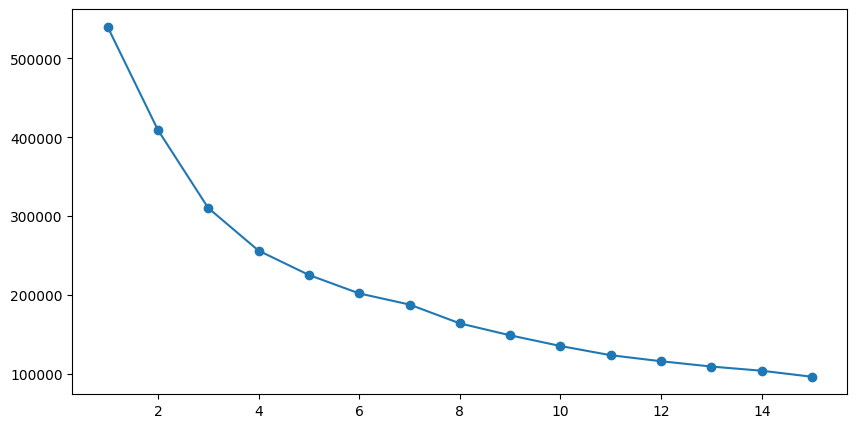

In [ ]:
# show the result in digram
plt.figure(figsize=(10,5))
plt.plot(range(1,16), sse_2, marker="o")

**Insight**

The Elbow Method suggests that the optimal number of clusters lies around k = 5 to 6. Adding the temporal feature (hour) did not significantly change the optimal cluster count, but it may influence cluster structure.

**3- Hyperparameter Tuning**

1- First Kmeans

In [ ]:
# Train model when n=5
kmeans2_5 = KMeans(n_clusters=5, random_state=42 ,n_init= 3 , max_iter= 100)
labels2_5 = kmeans2_5.fit_predict(y_scaled)
# calc score of the model
score2_5 = silhouette_score(y_scaled, labels2_5)
print(score2_5)

0.3393552


In [ ]:
# Train model when n=6
kmeans2_6 = KMeans(n_clusters=6, random_state=42 ,n_init=  10, max_iter= 200)
labels2_6 = kmeans2_6.fit_predict(y_scaled)
# calc score of the model
score2_6 = silhouette_score(y_scaled, labels2_6)
print(score2_6)

0.3450771


In [ ]:
# Final Kmeans Model
final_kmeans2 = KMeans(n_clusters=6, random_state=42 ,n_init=  10, max_iter= 200)
final_kmeans2_labels = final_kmeans2.fit_predict(y_scaled)

**Insight**

The optimal number of clusters for KMeans was found to be k = 6, as it provided better cluster separation compared to k = 5. Increasing n_init and max_iter improved model stability, leading to a more consistent clustering result.

2- Second DBSCAN

In [ ]:
# First we change the value of ebs
ebs_values = [.1 ,.3 ,.5 ,.7 ,.9]

for n_ebs in ebs_values:
  dbscan2 = DBSCAN(eps=n_ebs , min_samples=5)
  labels2 = dbscan2.fit_predict(y_sample_scaled)

  # Detrmine number of cluster
  n_clusters = len(set(labels2)) - (1 if -1 in labels2 else 0)

  # Detrmine noise ratio
  noise_ratio = np.sum(labels2 == -1) / len(labels2)

  # show the result
  print(f"eps={n_ebs}")
  print("Number of clusters:", n_clusters)
  print("Noise ratio:", noise_ratio)
  print("*"*50)

eps=0.1
Number of clusters: 303
Noise ratio: 0.1399
**************************************************
eps=0.3
Number of clusters: 28
Noise ratio: 0.028166666666666666
**************************************************
eps=0.5
Number of clusters: 6
Noise ratio: 0.012933333333333333
**************************************************
eps=0.7
Number of clusters: 7
Noise ratio: 0.0084
**************************************************
eps=0.9
Number of clusters: 4
Noise ratio: 0.0055
**************************************************


**Insight**

DBSCAN showed high sensitivity to the eps parameter. A small eps value led to excessive fragmentation, while larger values merged clusters. The optimal balance was achieved at eps = 0.5, producing a reasonable number of clusters with low noise.

Note => Although eps = 0.7 resulted in slightly lower noise, eps = 0.5 was selected as it provides a better balance between cluster separation and interpretability, and aligns with KMeans results.

In [ ]:
# Second change the value of min_samples
min_samples_values = [3 ,5 ,8 ,10]
for n_min_samples in min_samples_values:
  dbscan2 = DBSCAN(eps=.5 , min_samples=n_min_samples)
  labels2 = dbscan2.fit_predict(y_sample_scaled)

  # Detrmine number of cluster
  n_clusters = len(set(labels2)) - (1 if -1 in labels2 else 0)

  # Detrmine noise ratio
  noise_ratio = np.sum(labels2 == -1) / len(labels2)

  # Show the result
  print(f"min_samples={n_min_samples}")
  print("Number of clusters:", n_clusters)
  print("Noise ratio:", noise_ratio)
  print("*"*50)

min_samples=3
Number of clusters: 28
Noise ratio: 0.009466666666666667
**************************************************
min_samples=5
Number of clusters: 6
Noise ratio: 0.012933333333333333
**************************************************
min_samples=8
Number of clusters: 6
Noise ratio: 0.015333333333333332
**************************************************
min_samples=10
Number of clusters: 4
Noise ratio: 0.018466666666666666
**************************************************


**Insight**

The min_samples parameter controls cluster density. Lower values resulted in excessive fragmentation, while higher values merged clusters. The optimal setting was min_samples = 5, providing a balanced number of clusters with low noise.

In [ ]:
# final DBSCAN Model
final_dbscan2 = DBSCAN(eps=.7 , min_samples=5)
final_dbscan2_labels = final_dbscan2.fit_predict(y_sample_scaled)

**Insight**

DBSCAN performance depends on balancing eps and min_samples. While eps defines the spatial reach of clusters, min_samples controls their density, and both must be tuned together to achieve meaningful clustering. The optimal configuration (eps = 0.7, min_samples = 5) provided a well-balanced clustering structure with minimal noise and interpretable spatial patterns.

**4- Add Cluster**

In [ ]:
# Add Kmean cluster
df["kmeans2_cluster"] = final_kmeans2_labels

In [ ]:
# Add DBSCAN Cluster
df_sample["dbscan2_cluster"] = final_dbscan2_labels

In [ ]:
# Check
df.head()

,Lat,Lon,hour,is_wekend,kmeans_cluster,kmeans2_cluster
0,40.8021,-73.9654,10,0,1,5
1,40.6462,-73.7769,4,0,4,4
2,40.7747,-73.9603,9,0,1,2
3,40.7150,-74.0157,23,0,3,1
4,40.7335,-74.0080,19,1,3,1


In [ ]:
# check
df_sample.head()

,Lat,Lon,hour,is_wekend,dbscan_cluster,dbscan2_cluster
123137,40.7044,-73.9866,2,0,0,0
130504,40.7573,-73.9896,6,0,0,0
31166,40.6904,-74.1784,13,1,1,1
26262,40.7325,-73.9853,23,1,0,0
64868,40.7588,-73.9939,15,1,0,0


**5- Visualization**

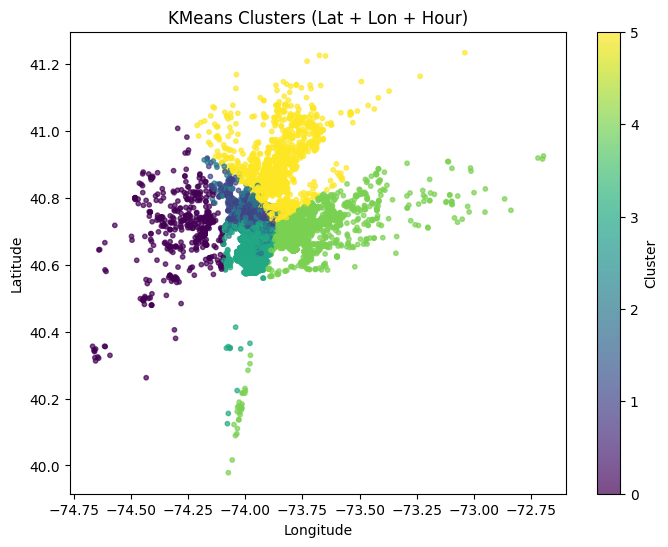

In [ ]:
# Display Kmeans cluster in Scatter
plt.figure(figsize=(8,6))
plt.scatter(df["Lon"], df["Lat"], c=df["kmeans2_cluster"], cmap="viridis", s=10, alpha=0.7)
plt.colorbar(label="Cluster")
plt.title("KMeans Clusters (Lat + Lon + Hour)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

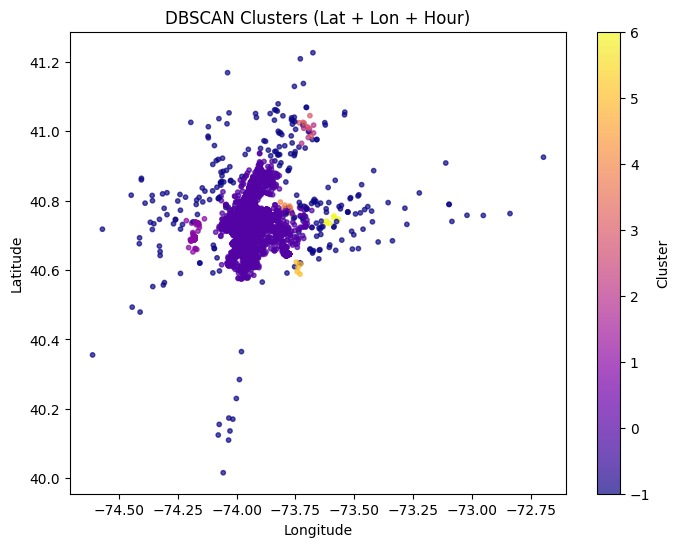

In [ ]:
# Display DBSCAN cluster in Scatter
plt.figure(figsize=(8,6))
plt.scatter(df_sample["Lon"], df_sample["Lat"], c=df_sample["dbscan2_cluster"], cmap="plasma", s=10, alpha=0.7)
plt.colorbar(label="Cluster")
plt.title("DBSCAN Clusters (Lat + Lon + Hour)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**Insight**

Adding the temporal feature (hour) improved KMeans clustering by refining cluster boundaries and capturing temporal variations. However, it negatively impacted DBSCAN performance by distorting distance calculations, leading to less distinct clusters.

**6- Evalution**

In [ ]:
# Evalution Kmeans

kmeans2_score = silhouette_score(y_scaled, df["kmeans2_cluster"])
print("KMeans Silhouette:", kmeans2_score)

KMeans Silhouette: 0.3450771


In [ ]:
# Evalution DBSCAN

# Filter noise
mask2 = final_dbscan2_labels != -1

dbscan2_score = silhouette_score(y_sample_scaled[mask2], labels2[mask2])
print("DBSCAN Silhouette:", dbscan2_score)

DBSCAN Silhouette: 0.5175909632034791


**7- Interpretation (Insights)**

In [ ]:
# Compare Between the two in the two expermient in dataframe

# Dictonary contain final comparison
data = {
    "Model": ["KMeans", "DBSCAN", "KMeans", "DBSCAN"],
    "Features Used": ["Lat + Lon", "Lat + Lon", "Lat + Lon + Hour", "Lat + Lon + Hour"],
    "Silhouette Score": [0.455, 0.669, 0.345, 0.517],
    "Performance Level": ["Good", "Excellent", "Moderate", "Very Good"],
    "Interpretation Level": ["Low", "Medium", "High", "Very High"],
    "Key Observation": ["Spatial only","Best density detection","Captures time but less separation","Best balance (space + time)"]
}

# Convert Dictonary to datarame
df_table = pd.DataFrame(data)
df_table

,Model,Features Used,Silhouette Score,Performance Level,Interpretation Level,Key Observation
0,KMeans,Lat + Lon,0.455,Good,Low,Spatial only
1,DBSCAN,Lat + Lon,0.669,Excellent,Medium,Best density detection
2,KMeans,Lat + Lon + Hour,0.345,Moderate,High,Captures time but less separation
3,DBSCAN,Lat + Lon + Hour,0.517,Very Good,Very High,Best balance (space + time)


**Comparison Result** => This project highlights the trade-off between model performance and interpretability, where simpler models achieve higher scores, while more complex feature sets provide deeper understanding of the data.

**Final Insights**
* DBSCAN consistently outperformed KMeans in both experiments, indicating that density-based clustering is more suitable for spatial data.
* DBSCAN consistently outperformed KMeans in both experiments, indicating that density-based clustering is more suitable for spatial data.
* KMeans produces structured partitions, while DBSCAN identifies natural clusters and noise, making it more flexible for real-world data.
* KMeans produces structured partitions, while DBSCAN identifies natural clusters and noise, making it more flexible for real-world data.
* The best overall approach is DBSCAN with spatial and temporal features, as it provides a balance between strong performance and meaningful real-world insights.


# **8- Cluster Membership using KNN**

1. Spliting
2. Train Pipline
3. Evaluation

**Step Description**
* In this step, the clustering results are transformed into a supervised learning problem.
* The cluster labels generated by DBSCAN are used as target variables, while the original features (such as latitude, longitude, and hour) are used as input features.
* A KNN model is then trained on this data to learn the relationship between input features and cluster assignments, enabling the system to assign new incoming data points to the most appropriate cluster.
* This step effectively bridges the gap between unsupervised clustering and real-world prediction.

**1- Spliting**

In [ ]:
# Import
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import joblib

In [ ]:
# For first Experiment
x_dbscan = df_sample[["Lat", "Lon"]]
y_dbscan = df_sample["dbscan_cluster"]
# For Two Expermient
x_dbscan2 = df_sample[["Lat", "Lon", "hour"]]
y_dbscan2 = df_sample["dbscan2_cluster"]

# divide data into train data and test data
x_dbscan_train,x_dbscan_test,y_dbscan_train,y_dbscan_test = train_test_split(x_dbscan,y_dbscan,test_size=0.25,random_state=42,stratify=y_dbscan,shuffle=True)
x_dbscan2_train,x_dbscan2_test,y_dbscan2_train,y_dbscan2_test = train_test_split(x_dbscan2,y_dbscan2,test_size=0.25,random_state=42,stratify=y_dbscan2,shuffle=True)

In [ ]:
# Spatial Pipeline
pipeline_spatial = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

pipeline_spatial.fit(x_dbscan_train, y_dbscan_train)


# Temporal Pipeline
pipeline_temporal = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

pipeline_temporal.fit(x_dbscan2_train, y_dbscan2_train)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

**3- Evaluation**

In [ ]:
print("Spatial Train:", pipeline_spatial.score(x_dbscan_train, y_dbscan_train))
print("Spatial Test :", pipeline_spatial.score(x_dbscan_test, y_dbscan_test))

print("Temporal Train:", pipeline_temporal.score(x_dbscan2_train, y_dbscan2_train))
print("Temporal Test :", pipeline_temporal.score(x_dbscan2_test, y_dbscan2_test))

Spatial Train: 0.9991111111111111
Spatial Test : 0.9992
Temporal Train: 0.9990222222222223
Temporal Test : 0.9977333333333334


**Insight**

The extremely high accuracy is expected since KNN is trained to replicate DBSCAN-generated labels, making the task inherently easier. The spatial model performs slightly better due to clearer geographic separation, while adding the temporal feature introduces additional complexity that slightly reduces performance.

In [ ]:
df["Lat"].min() , df["Lat"].max() ,df["Lon"].min() , df["Lon"].max()

(39.9782, 41.2339, -74.6674, -72.6966)

**9- Model Deployment**

In [ ]:
# Save Models
joblib.dump(pipeline_spatial, "pipeline_spatial.pkl")
joblib.dump(pipeline_temporal, "pipeline_temporal.pkl")
joblib.dump(final_dbscan , "DBSCAN_spatial.pkl")
joblib.dump(final_dbscan2 , "DBSCAN_temporal.pkl")

['DBSCAN_temporal.pkl']

In [ ]:
# Save Final Data
df_sample.to_csv("final_data_Used_In_DBSCAN.csv", index=False)

In [ ]:
# Download Model in your PC
# from google.colab import files
# files.download("pipeline_spatial.pkl")
# files.download("pipeline_temporal.pkl")
# files.download("DBSCAN_spatial.pkl")
# files.download("DBSCAN_temporal.pkl")
# Download Final Data
# files.download("final_data_Used_In_DBSCAN.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 63.3 MB/s eta 0:00:00


# Display Model In GUI

In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import plotly.express as px
from datetime import datetime

# Load Data (Processed)
df = pd.read_csv("final_data_Used_In_DBSCAN.csv")

# Load Models (Pipelines)
pipeline_spatial = joblib.load("pipeline_spatial.pkl")
pipeline_temporal = joblib.load("pipeline_temporal.pkl")

# Sidebar
st.sidebar.title("🚖 Uber Clustering Dashboard")
page = st.sidebar.radio("Navigation", [
    "📊 Unsupervised Analysis",
    "🎯 Cluster Membership"
])

# 🟢 PAGE 1 → Unsupervised Analysis
if page == "📊 Unsupervised Analysis":

    st.title("📊 DBSCAN Clustering Analysis")

    st.markdown("### 🔹 Spatial Clustering (Lat + Lon)")

    fig1 = px.scatter(
        df,
        x="Lon",
        y="Lat",
        color=df["dbscan_cluster"].astype(str),
        title="DBSCAN Spatial Clusters",
        opacity=0.6
    )
    st.plotly_chart(fig1, use_container_width=True)

    st.markdown("### 🔹 Spatio-temporal Clustering (Lat + Lon + Hour)")

    fig2 = px.scatter(
        df,
        x="Lon",
        y="Lat",
        color=df["dbscan2_cluster"].astype(str),
        title="DBSCAN Spatio-temporal Clusters",
        opacity=0.6
    )
    st.plotly_chart(fig2, use_container_width=True)

    st.markdown("### 💡 Insight")

    st.info("""
    - Spatial clustering groups trips based only on geographic location.
    - Adding time (hour) creates more refined clusters.
    - Some large clusters are split into smaller, time-dependent patterns.
    """)

# 🔴 PAGE 2 → Cluster Membership (Prediction)
else:

    st.title("🎯 Cluster Membership Prediction")

    st.markdown("### 📥 Input")

    # Inputs
    lat = st.number_input("Latitude", value=40.7)
    lon = st.number_input("Longitude", value=-73.9)

    date = st.date_input("Date 📅")
    time = st.time_input("Time ⏰")

    mode = st.radio("Mode", [
        "Spatial (Location Only)",
        "Spatio-temporal (Location + Time)"
    ])

    # Predict Button
    if st.button("🚀  Cluster Membership"):

        # Extract hour
        hour = datetime.combine(date, time).hour

        # Prediction
        if mode == "Spatial (Location Only)":
            input_df = pd.DataFrame([[lat, lon]], columns=["Lat", "Lon"])
            cluster = pipeline_spatial.predict(input_df)[0]
            cluster_col = "dbscan_cluster"

        else:
            input_df = pd.DataFrame([[lat, lon, hour]], columns=["Lat", "Lon", "hour"])
            cluster = pipeline_temporal.predict(input_df)[0]
            cluster_col = "dbscan2_cluster"

        # Result
        st.success(f"✅ Cluster: {cluster}")

        # Visualization
        st.markdown("### 📊 Visualization")

        df["color"] = "Other"
        df.loc[df[cluster_col] == cluster, "color"] = "Selected Cluster"

        fig = px.scatter(
            df,
            x="Lon",
            y="Lat",
            color="color",
            color_discrete_map={
                "Other": "lightgray",
                "Selected Cluster": "blue"
            },
            opacity=0.5,
            title="Cluster Highlight"
        )

        # 🔴 User Point
        fig.add_scatter(
            x=[lon],
            y=[lat],
            mode="markers",
            marker=dict(color="red", size=12),
            name="Your Point 🔴"
        )

        st.plotly_chart(fig, use_container_width=True)

        # Insight
        st.markdown("### 💡 Insight")

        if mode == "Spatial (Location Only)":
            st.info("""
            This point belongs to a geographically dense cluster.
            The prediction is based on spatial proximity to historical pickup locations.
            """)
        else:
            st.info(f"""
            This point belongs to a spatio-temporal cluster.
            The hour ({hour}) influenced the cluster assignment, capturing time-based patterns.
            """)

Overwriting app.py


In [ ]:
# Download app on pc
# from google.colab import files
# files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>